Start from the dataset kickstarter-14-04, take out the unnecessary columsn that I don't know why are there:

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import nltk
from nltk.corpus import stopwords
import string 
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
import re 
from collections import Counter
import ast
import glob
from collections import Counter
from scipy import stats

In [2]:
campaigns = pd.read_csv('raw_kickstarter.csv', index_col=0)
campaigns

,url,title,description,pledged,usd_pledged,converted_pledged_amount,goal,currency
0,https://www.kickstarter.com/projects/thetruthb...,NaN,The PROBLEM: So much entertainment today pushe...,71123.0,71123.0,61607,48000.0,USD
1,https://www.kickstarter.com/projects/99625582/...,NaN,Millions of American college students have stu...,65318.0,65318.0,56579,61500.0,USD
2,https://www.kickstarter.com/projects/distortre...,Cartoon Network Alphabet Pins,Full A-Z Set I'm launching this set to show my...,462.0,462.0,400,8000.0,USD
3,https://www.kickstarter.com/projects/jordym/th...,The Balloon - a short film,"On a sleepy summer afternoon, we stared into t...",5137.0,5137.0,4449,15000.0,USD
4,https://www.kickstarter.com/projects/trans-mov...,NaN,48 hours of pledge matching! Amazing news! Two...,50640.0,50640.0,43865,50000.0,USD
...,...,...,...,...,...,...,...,...
8390,https://www.kickstarter.com/projects/zerwcolla...,ZerwCollab: Your AI-Powered App Builder in Sec...,🚀 What If You Could Launch a Website or App… U...,2128.0,2128.0,1823,35900.0,USD
8391,https://www.kickstarter.com/projects/jacobzirk...,VFX Oasis: Free VFX Assets and Footage,What is VFX Oasis? VFX Oasis is an industry fo...,580.0,580.0,496,6000.0,USD
8392,https://www.kickstarter.com/projects/153189407...,Sharp X - Edge Gadget,Kickstarter Project Story – USA-Market Sharpen...,857.0,857.0,734,7800.0,USD
8393,https://www.kickstarter.com/projects/diyengine...,Steady Shot Bot: Hyperlapse + Steadycam + Auto...,"Why As a hobbyist, I recently found myself wan...",6645.0,6645.0,5693,310000.0,USD


### as a very first step we add the categories to each project

In [3]:

folder_path = "Kickstarter_2026-03-12T03_20_26_556Z"

files = glob.glob(f"{folder_path}/*.csv")

print("Number of files found:", len(files))

dfs = []

for file in files:
    print("Loading:", file)
    df_temp = pd.read_csv(file)
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)


launched = {}
url_to_category = {}
deadline = {}
video = {}
for _, row in df.iterrows():
    parsed = ast.literal_eval(row['category'])
    parent_name = parsed.get('parent_name') or parsed.get('name')
    url_parsed = ast.literal_eval(row['urls'])
    project_url = url_parsed['web']['project']
    url_to_category[project_url] = parent_name
    launched[project_url] = row['launched_at']
    deadline[project_url] = row['deadline']
    video[project_url] = row['video']

campaigns['category'] = campaigns['url'].map(url_to_category)
campaigns['launched_at'] = campaigns['url'].map(launched)
campaigns['deadline'] = campaigns['url'].map(deadline)
campaigns['video'] = campaigns['url'].map(video)
 
print(f"Matched: {campaigns['category'].notna().sum()} / {len(campaigns)}")
print(campaigns['category'].value_counts())

Number of files found: 85
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter001.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter002.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter003.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter004.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter005.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter006.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter007.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter008.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter009.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter010.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter011.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter012.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter013.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter014.csv
Lo

take out the unnecessary columns, add the reached one and classify as success or failure (maybe it's already in the initial dataset but honestly I don't remember)

In [4]:
campaigns[campaigns['video'].isna()]

,url,title,description,pledged,usd_pledged,converted_pledged_amount,goal,currency,category,launched_at,deadline,video
7,https://www.kickstarter.com/projects/themonkey...,Golden Goalie,Join Me Join me in a new community of Golden G...,316.0,316.0,273,15000.0,USD,Games,1715101573,1717693573,NaN
38,https://www.kickstarter.com/projects/824417104...,LOSS Red Carpet Film Premiere!,LOSS was filmed locally in the Greater Seattle...,2255.0,2255.0,1953,15000.0,USD,Film & Video,1471874563,1473490740,NaN
44,https://www.kickstarter.com/projects/schemers/...,NaN,"1899 DAIHAN In 1899, the Seoul-Incheon railway...",38772.0,38772.0,33587,20000.0,USD,Games,1732003451,1736139600,NaN
61,https://www.kickstarter.com/projects/asfuller/...,NaN,header image: Covers from four issues of 3LBE ...,11302.0,11302.0,9790,10000.0,USD,Publishing,1755014456,1757606456,NaN
69,https://www.kickstarter.com/projects/justdizle...,DJ Just Dizle Music Videos,You'll need an HTML5 capable browser to see th...,1964.0,1964.0,1701,11200.0,USD,Film & Video,1664253702,1666845702,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
8363,https://www.kickstarter.com/projects/295120209...,"The Blastone, a high quality Bluetooth music r...","Forget those wimpy, poor sounding, ""Bluetooth ...",1666.0,1666.0,1427,30000.0,USD,Technology,1403005977,1405597977,NaN
8365,https://www.kickstarter.com/projects/201879354...,Venus Rising Project,This is a project dedicated to providing a saf...,1746.0,1746.0,1496,10000.0,USD,Technology,1525498032,1528090032,NaN
8366,https://www.kickstarter.com/projects/191167207...,Samsung Gear VR Head Mounted Display Adapter b...,Head Mounted Display Adapter for the Samsung G...,189.0,189.0,161,7500.0,USD,Technology,1459468466,1462060466,NaN
8380,https://www.kickstarter.com/projects/nomajors/...,NO MAJORS MUSIC,Help Us Launch NO MAJORS – The Indie Music Rev...,203.0,203.0,173,17600.0,USD,Technology,1742276092,1747460092,NaN


In [5]:
campaigns['reached'] = (campaigns['pledged'] / campaigns['goal']) * 100

campaigns['status'] = campaigns['reached'].apply(lambda x: 1 if x >= 100 else 0)

campaigns['video']  = campaigns['video'].apply(lambda x: 0 if type(x) == float else 1)

campaigns['duration'] = (pd.to_datetime(campaigns['deadline'], unit ='s') - pd.to_datetime(campaigns['launched_at'], unit = 's')).dt.days

campaigns = campaigns.drop(columns= ['launched_at', 'deadline'])

In [76]:
campaigns

,url,title,description,pledged,usd_pledged,converted_pledged_amount,goal,currency,category,video,reached,status,duration
0,https://www.kickstarter.com/projects/thetruthb...,NaN,The PROBLEM: So much entertainment today pushe...,71123.0,71123.0,61607,48000.0,USD,Film & Video,1,148.172917,1,30
1,https://www.kickstarter.com/projects/99625582/...,NaN,Millions of American college students have stu...,65318.0,65318.0,56579,61500.0,USD,Film & Video,1,106.208130,1,41
2,https://www.kickstarter.com/projects/distortre...,Cartoon Network Alphabet Pins,Full A-Z Set I'm launching this set to show my...,462.0,462.0,400,8000.0,USD,Film & Video,1,5.775000,0,45
3,https://www.kickstarter.com/projects/jordym/th...,The Balloon - a short film,"On a sleepy summer afternoon, we stared into t...",5137.0,5137.0,4449,15000.0,USD,Film & Video,1,34.246667,0,60
4,https://www.kickstarter.com/projects/trans-mov...,NaN,48 hours of pledge matching! Amazing news! Two...,50640.0,50640.0,43865,50000.0,USD,Film & Video,1,101.280000,1,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8390,https://www.kickstarter.com/projects/zerwcolla...,ZerwCollab: Your AI-Powered App Builder in Sec...,🚀 What If You Could Launch a Website or App… U...,2128.0,2128.0,1823,35900.0,USD,Technology,0,5.927577,0,27
8391,https://www.kickstarter.com/projects/jacobzirk...,VFX Oasis: Free VFX Assets and Footage,What is VFX Oasis? VFX Oasis is an industry fo...,580.0,580.0,496,6000.0,USD,Technology,1,9.666667,0,30
8392,https://www.kickstarter.com/projects/153189407...,Sharp X - Edge Gadget,Kickstarter Project Story – USA-Market Sharpen...,857.0,857.0,734,7800.0,USD,Technology,1,10.987179,0,53
8393,https://www.kickstarter.com/projects/diyengine...,Steady Shot Bot: Hyperlapse + Steadycam + Auto...,"Why As a hobbyist, I recently found myself wan...",6645.0,6645.0,5693,310000.0,USD,Technology,1,2.143548,0,40


Preprocessing: usual preprocessing stuff like lowercasing, taking out links, only keepin alpha numeric characters, tokenizing the words, and taking out the english stopwords, also took out the words that are less than 2 characters

In [6]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text_p = "".join([char for char in text if char.isalnum() or char.isspace()])
    
    words = word_tokenize(text_p) 
    
    
    stop_words = stopwords.words('english')
    words = [w for w in words if w not in stop_words and len(w) > 2 and w.isalpha()]
    filtered_words = [word for word in words if word not in stop_words] 
    
    return filtered_words  

campaigns['description_processed'] = campaigns['description'].apply(preprocess)

How do we decide which stopwords to include beside the 'normal' stopwords? We also want to include words that are very generic, not informative at all and coudl potentially appear in any kind of campaign, regardless of the topics in it (some examples could be the words 'kickstarter', campaign, etc etc)
Initially I thought TF-IDF would make sense but it doesn't actually, because TF-IDF both depends on how frequent a word is in each document and how frequent are documents that contain that words in the whole set of documents. (also you cannot average the TF-IDF of a word and pick the ones with lowest value because a rare word, which we wanna keep, could end up having a low TF-IDF value if it appears in few documents but many time in those few documents)
So potentially we can just use document frequency, meaning if the word appears in > alpha% of documents, we count it as a stopword?

Also quick sidenote: Other methods like BytePair encoding, WordPiece or SentencePiece are not really useful here because they look at subwords, and for example if we get 'kickstarter' and split it into kick and starter, then we might consider to keep kick because it makes sense with sport but we might not have any document where the word is present for real

This below just basically gives a counter of the document frequency of each token in our whole corpus of all the descriptions 

We apply lemmatization (I think probably better than stemming since it returns the lemma version of the word, instead of just cutting the ending of the word). We apply it now, before taking out the domain specific stopwords, because otherwise we could end up having to account for different versions of the same stopword (example: project vs projects)

In [ ]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return 'a'
    if treebank_tag.startswith('V'):
        return 'v'
    if treebank_tag.startswith('N'):
        return 'n'
    if treebank_tag.startswith('R'):
        return 'r'
    return 'n'

# here basically for all tokens you assign POS to get (token, POS) through ntlk
campaigns['pos_tagged'] = campaigns['description_processed'].apply(nltk.pos_tag)


# now here you lemmatize the POS-tagged tokens, meaning if before you had tokens 'run' and 
# 'running' as the couple (token, 'Verb'), now those couple are fed into the lemmatization 
# to get out a single token (run)
campaigns['lemmatized'] = campaigns['pos_tagged'].apply(
    lambda tagged_words: [
        lemmatizer.lemmatize(word, get_wordnet_pos(pos))
        for word, pos in tagged_words
    ]
)



In [79]:

pos_tagged_verbs = [
    word
    for tagged_words in campaigns['pos_tagged']
    for word, pos in tagged_words
    if pos.startswith('VB')
]
pos_tagged_nouns = [
    word
    for tagged_words in campaigns['pos_tagged']
    for word, pos in tagged_words
    if pos.startswith('NN')
]

# 4) Verb/Noun extraction from POS-aware lemmatized tokens
lemma_verbs = [
    lemmatizer.lemmatize(word, 'v')
    for tagged_words in campaigns['pos_tagged']
    for word, pos in tagged_words
    if pos.startswith('VB')
]
lemma_nouns = [
    lemmatizer.lemmatize(word, 'n')
    for tagged_words in campaigns['pos_tagged']
    for word, pos in tagged_words
    if pos.startswith('NN')
]


# Optional unique vocab views
print("\nUnique vocab sizes:")
print(f"Unique POS-tagged verbs: {len(set(pos_tagged_verbs))}")
print(f"Unique POS-tagged nouns: {len(set(pos_tagged_nouns))}")
print(f"Unique lemmatized verbs: {len(set(lemma_verbs))}")
print(f"Unique lemmatized nouns: {len(set(lemma_nouns))}")


Unique vocab sizes:
Unique POS-tagged verbs: 41605
Unique POS-tagged nouns: 79021
Unique lemmatized verbs: 34393
Unique lemmatized nouns: 71342


In [80]:
init = ['running']
couple = nltk.pos_tag(init)
print(couple)

word = lemmatizer.lemmatize(couple[0][0], get_wordnet_pos(couple[0][1]))
print(word)

[('running', 'VBG')]
run


In [13]:
initial_vocab = set(token for doc in campaigns['lemmatized'] for token in doc)
print(f"lenght of the initial vocabulary: {len(initial_vocab)}")

lenght of the initial vocabulary: 110954


zipf's law demonstration in our dataset:
                word  frequency    rank  cumsum_freq  cumsum_pct
0              make      24299       1        24299    0.613764
1              film      20237       2        44536    1.124927
2              game      19927       3        64463    1.628259
3              work      17544       4        82007    2.071400
4               one      16423       5        98430    2.486226
...             ...        ...     ...          ...         ...
110949    makingand          1  110950      3959009   99.999899
110950  excitingnot          1  110951      3959010   99.999924
110951        barrs          1  110952      3959011   99.999949
110952    harradons          1  110953      3959012   99.999975
110953     dargenio          1  110954      3959013  100.000000

[110954 rows x 5 columns]


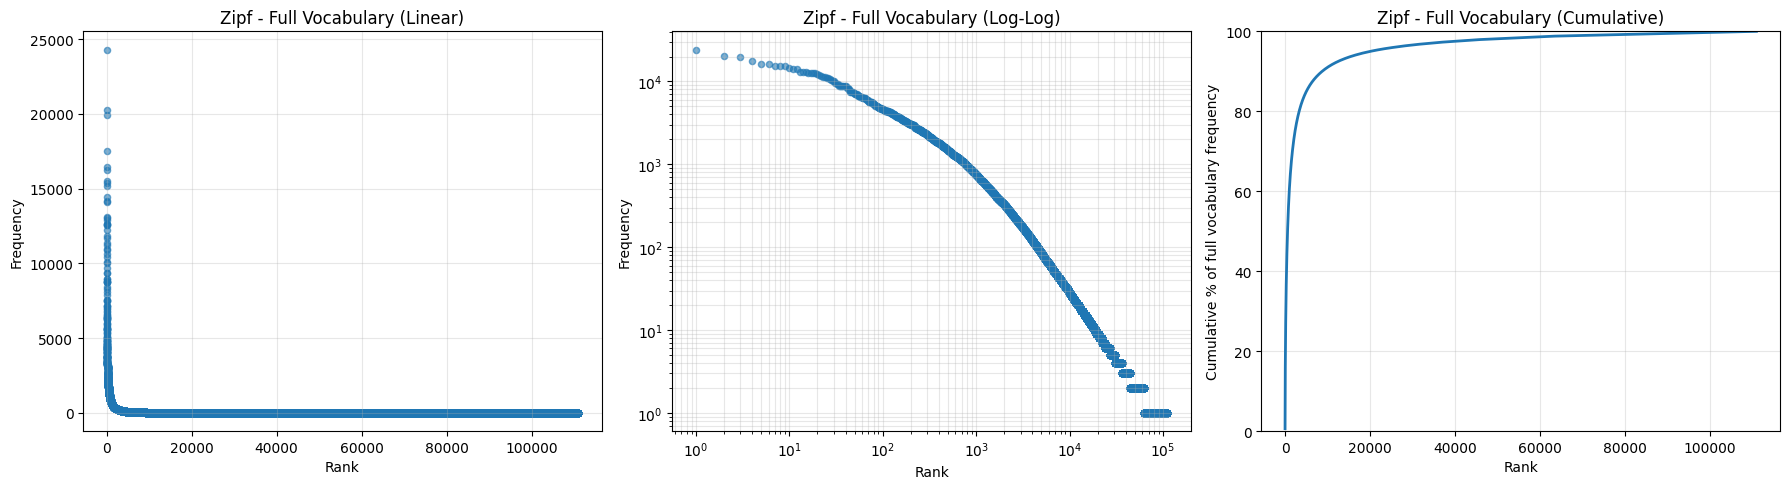

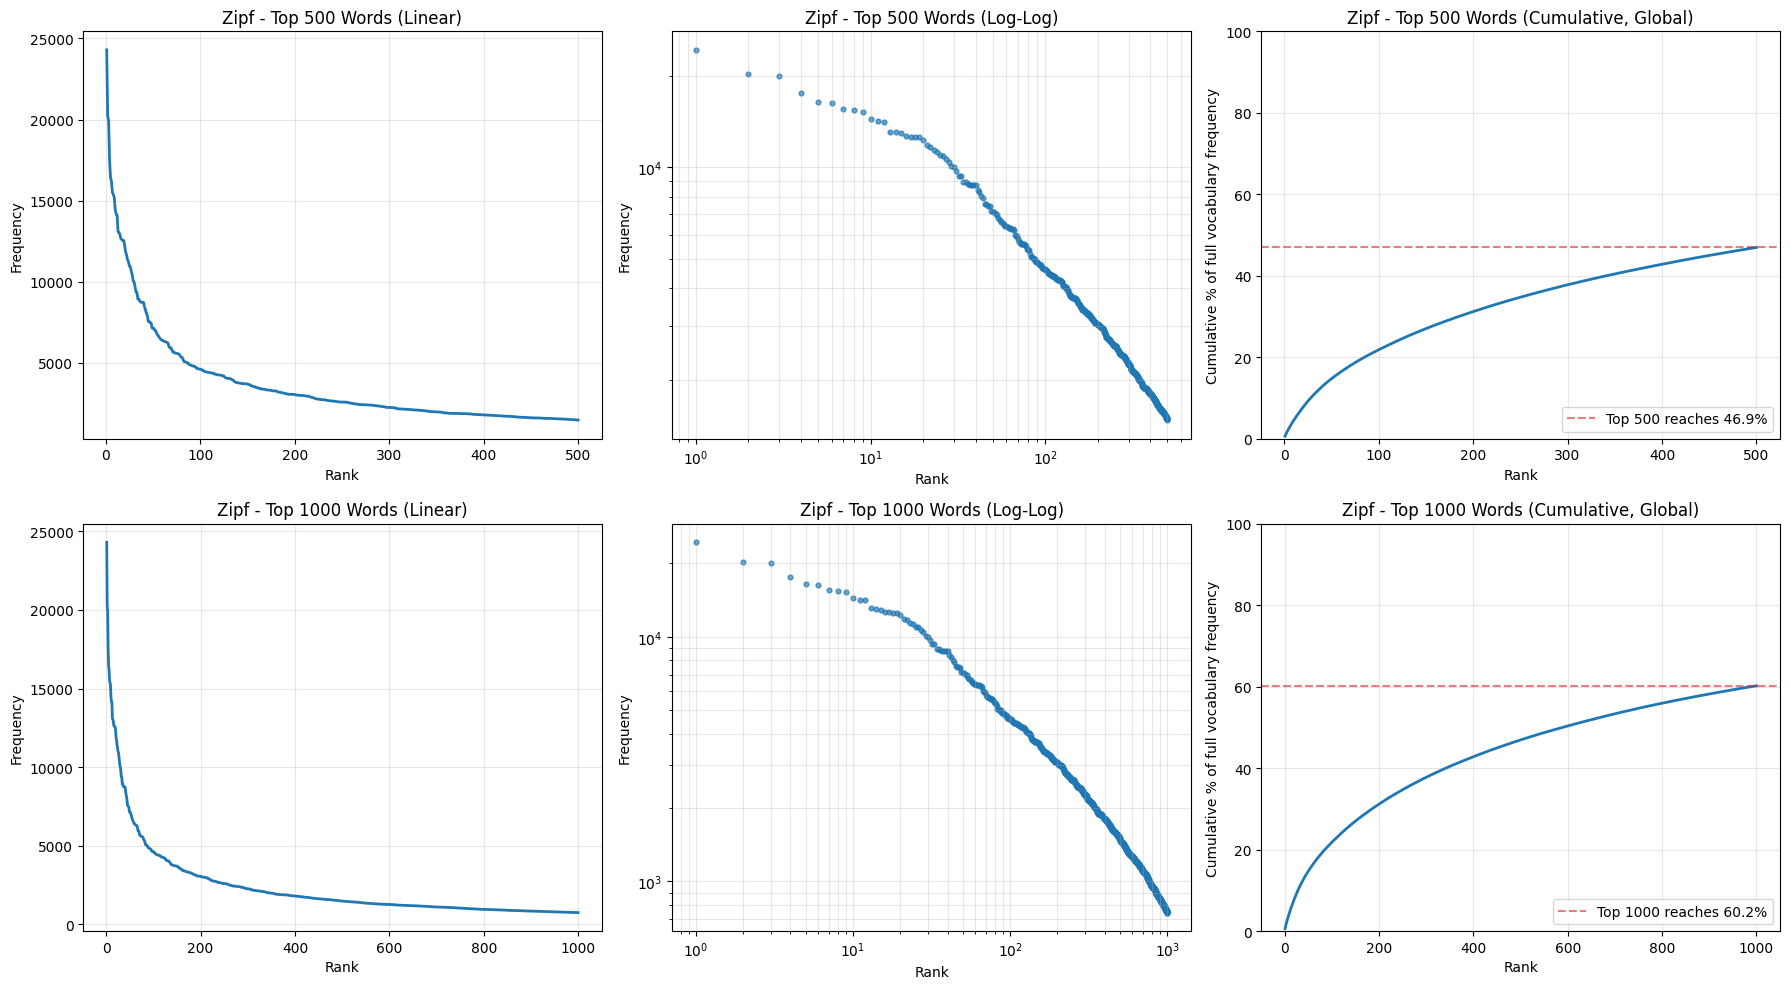

In [14]:
term_freq_counter = Counter()
for doc in campaigns["lemmatized"]:
    # Zipf should use total token frequency, not document presence.
    term_freq_counter.update(doc)

zipf_df = pd.DataFrame({
    'word': list(term_freq_counter.keys()),
    'frequency': list(term_freq_counter.values())
}).sort_values('frequency', ascending=False).reset_index(drop=True)

# Add rank (1-indexed) and cumulative percentage on full vocabulary
zipf_df['rank'] = range(1, len(zipf_df) + 1)
zipf_df['cumsum_freq'] = zipf_df['frequency'].cumsum()
zipf_df['cumsum_pct'] = 100 * zipf_df['cumsum_freq'] / zipf_df['frequency'].sum()

print(f"zipf's law demonstration in our dataset:\n {zipf_df}")

# 1) Full vocabulary: frequency (linear + log-log) and cumulative
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(zipf_df['rank'], zipf_df['frequency'], alpha=0.6, s=20)
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Frequency')
axes[0].set_title("Zipf - Full Vocabulary (Linear)")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(zipf_df['rank'], zipf_df['frequency'], alpha=0.6, s=20)
axes[1].set_xlabel('Rank')
axes[1].set_ylabel('Frequency')
axes[1].set_title("Zipf - Full Vocabulary (Log-Log)")
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3, which='both')

axes[2].plot(zipf_df['rank'], zipf_df['cumsum_pct'], linewidth=2)
axes[2].set_xlabel('Rank')
axes[2].set_ylabel('Cumulative % of full vocabulary frequency')
axes[2].set_title("Zipf - Full Vocabulary (Cumulative)")
axes[2].set_ylim(0, 100)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2) Top 500 and Top 2000: frequency (linear + log-log) and cumulative
# Cumulative here is measured against FULL vocabulary total, so curves usually do not reach 100.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row_idx, top_n in enumerate([500, 1000]):
    top_df = zipf_df.head(top_n).copy()

    # Global cumulative at rank r (from full vocabulary denominator)
    top_df['global_cumsum_pct'] = top_df['cumsum_pct']
    max_global_pct = top_df['global_cumsum_pct'].iloc[-1]

    # Linear frequency
    axes[row_idx, 0].plot(top_df['rank'], top_df['frequency'], linewidth=2)
    axes[row_idx, 0].set_xlabel('Rank')
    axes[row_idx, 0].set_ylabel('Frequency')
    axes[row_idx, 0].set_title(f"Zipf - Top {top_n} Words (Linear)")
    axes[row_idx, 0].grid(True, alpha=0.3)

    # Log-log frequency
    axes[row_idx, 1].scatter(top_df['rank'], top_df['frequency'], s=12, alpha=0.7)
    axes[row_idx, 1].set_xlabel('Rank')
    axes[row_idx, 1].set_ylabel('Frequency')
    axes[row_idx, 1].set_title(f"Zipf - Top {top_n} Words (Log-Log)")
    axes[row_idx, 1].set_xscale('log')
    axes[row_idx, 1].set_yscale('log')
    axes[row_idx, 1].grid(True, alpha=0.3, which='both')

    # Cumulative against full vocabulary
    axes[row_idx, 2].plot(top_df['rank'], top_df['global_cumsum_pct'], linewidth=2)
    axes[row_idx, 2].axhline(max_global_pct, color='tab:red', linestyle='--', alpha=0.6,
                             label=f"Top {top_n} reaches {max_global_pct:.1f}%")
    axes[row_idx, 2].set_xlabel('Rank')
    axes[row_idx, 2].set_ylabel('Cumulative % of full vocabulary frequency')
    axes[row_idx, 2].set_title(f"Zipf - Top {top_n} Words (Cumulative, Global)")
    axes[row_idx, 2].set_ylim(0, 100)
    axes[row_idx, 2].grid(True, alpha=0.3)
    axes[row_idx, 2].legend(loc='lower right')


plt.tight_layout()
plt.show()

In [83]:
docs = campaigns['lemmatized']
N = len(docs)

df_counter = Counter()

for doc in docs:
    df_counter.update(set(doc))

df_table = pd.DataFrame({
    'word': list(df_counter.keys()),
    'doc_freq': list(df_counter.values())
})

df_table['doc_freq_ratio'] = df_table['doc_freq'] / N
df_table = df_table.sort_values('doc_freq_ratio', ascending=False)



In [16]:
print(f"total number of tokens is: {len(df_table)}")
df_table


total number of tokens is: 110954


,word,doc_freq,doc_freq_ratio
324,make,6131,0.833696
63,help,5236,0.711993
262,one,5194,0.706282
516,work,5178,0.704107
113,time,5136,0.698395
...,...,...,...
110941,connectorthe,1,0.000136
110940,recallable,1,0.000136
110939,amax,1,0.000136
110938,dbu,1,0.000136


Now the only method and the one that made most sense to me to take out too common words is basically just defining a threshold and see which words are too rare (like if it appears only 2-3 times in the whole dataset) or too much (in this case too much can be like appearing in more than 40-60% of the descriptions), you can try different values of the two initial thresholds (the one I saw looks the best would be 0.0005 for the low and 0.55 for the high)

In [85]:
min_doc_count = 10
min_ratio = min_doc_count / N
top_n_words = 150


top_words_preview = (
    df_table
    .sort_values('doc_freq_ratio', ascending=False)
    .head(top_n_words)
)

print(df_table[df_table['doc_freq_ratio'] <= min_ratio])
top_words_preview




                   word  doc_freq  doc_freq_ratio
88249              byte        10        0.001360
1              roulette        10        0.001360
40551          stuntman        10        0.001360
40582            arturo        10        0.001360
4682    injectionmolded        10        0.001360
...                 ...       ...             ...
110941     connectorthe         1        0.000136
110940       recallable         1        0.000136
110939             amax         1        0.000136
110938              dbu         1        0.000136
7        wholebiblelife         1        0.000136

[97057 rows x 3 columns]


,word,doc_freq,doc_freq_ratio
324,make,6131,0.833696
63,help,5236,0.711993
262,one,5194,0.706282
516,work,5178,0.704107
113,time,5136,0.698395
...,...,...,...
1396,ever,2009,0.273185
1866,game,2001,0.272097
862,never,1999,0.271825
524,pay,1978,0.268969


In [86]:
vocab = set(
    df_table['word']
)
print(f"length of initial vocabulary is {len(vocab)}")

rare_words = set(df_table['word'][df_table['doc_freq_ratio'] <= min_ratio] )


common_words = set(top_words_preview["word"])
vocab = vocab - common_words - rare_words
print(f"there are {len(common_words)} common words")
print(f"there are {len(rare_words)} rare words")
print(f"Removed {len(rare_words) + len(common_words)} words from vocab")
print(f"the vocabulary size now after having took out the general stopwords (not category specific) is {len(vocab)} tokens")
vocab

length of initial vocabulary is 110954
there are 150 common words
there are 97057 rare words
Removed 97207 words from vocab
the vocabulary size now after having took out the general stopwords (not category specific) is 13747 tokens


{'battlefield',
 'liner',
 'ceaseless',
 'perish',
 'bennett',
 'spear',
 'backing',
 'stamina',
 'shall',
 'filament',
 'driver',
 'union',
 'contrast',
 'lord',
 'appreciative',
 'homeland',
 'confronts',
 'wilma',
 'attire',
 'regime',
 'ellie',
 'intergenerational',
 'useless',
 'gilded',
 'sunflower',
 'jovial',
 'irregular',
 'grab',
 'original',
 'misadventure',
 'culminate',
 'wholesale',
 'onoff',
 'lauren',
 'kansas',
 'sander',
 'colorful',
 'delivers',
 'einstein',
 'parte',
 'clip',
 'little',
 'unofficial',
 'nyu',
 'script',
 'guitar',
 'responsibly',
 'korea',
 'reflective',
 'dispute',
 'cleverly',
 'firstedition',
 'gently',
 'unrelated',
 'competitor',
 'ableton',
 'reminiscent',
 'taker',
 'moisture',
 'pioneer',
 'flores',
 'interdisciplinary',
 'specter',
 'woodstock',
 'godfather',
 'hedgehog',
 'fragrance',
 'being',
 'training',
 'nickel',
 'navy',
 'flow',
 'hell',
 'invite',
 'comunidad',
 'fracture',
 'worthwhile',
 'news',
 'wonderfully',
 'simon',
 'preord

### Now we work on the data specific category by category 

In [87]:
# to actually take the overall common words out CAREFUL TO RUN 
campaigns['description_processed'] = campaigns['lemmatized'].apply(
    lambda doc: [w for w in doc if w in vocab]
)
campaigns = campaigns.drop(columns=['lemmatized'])

In [88]:
df = campaigns

In [ ]:
df = df.drop(columns = ['lemmatize'])
df

,url,title,description,pledged,usd_pledged,converted_pledged_amount,goal,currency,category,video,reached,status,duration,description_processed,pos_tagged
0,https://www.kickstarter.com/projects/thetruthb...,NaN,The PROBLEM: So much entertainment today pushe...,71123.0,71123.0,61607,48000.0,USD,Film & Video,1,148.172917,1,30,"[problem, entertainment, today, push, unholy, ...","[(problem, NN), (much, JJ), (entertainment, NN..."
1,https://www.kickstarter.com/projects/99625582/...,NaN,Millions of American college students have stu...,65318.0,65318.0,56579,61500.0,USD,Film & Video,1,106.208130,1,41,"[million, american, college, student, study, a...","[(millions, NNS), (american, JJ), (college, NN..."
2,https://www.kickstarter.com/projects/distortre...,Cartoon Network Alphabet Pins,Full A-Z Set I'm launching this set to show my...,462.0,462.0,400,8000.0,USD,Film & Video,1,5.775000,0,45,"[launch, early, cartoon, network, type, challe...","[(full, JJ), (set, NN), (launching, VBG), (set..."
3,https://www.kickstarter.com/projects/jordym/th...,The Balloon - a short film,"On a sleepy summer afternoon, we stared into t...",5137.0,5137.0,4449,15000.0,USD,Film & Video,1,34.246667,0,60,"[sleepy, summer, afternoon, star, void, float,...","[(sleepy, NN), (summer, NN), (afternoon, NN), ..."
4,https://www.kickstarter.com/projects/trans-mov...,NaN,48 hours of pledge matching! Amazing news! Two...,50640.0,50640.0,43865,50000.0,USD,Film & Video,1,101.280000,1,30,"[hour, pledge, match, amaze, news, generous, m...","[(hours, NNS), (pledge, VBP), (matching, VBG),..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8390,https://www.kickstarter.com/projects/zerwcolla...,ZerwCollab: Your AI-Powered App Builder in Sec...,🚀 What If You Could Launch a Website or App… U...,2128.0,2128.0,1823,35900.0,USD,Technology,0,5.927577,0,27,"[launch, website, app, voice, imagine, website...","[(could, MD), (launch, VB), (website, JJ), (ap..."
8391,https://www.kickstarter.com/projects/jacobzirk...,VFX Oasis: Free VFX Assets and Footage,What is VFX Oasis? VFX Oasis is an industry fo...,580.0,580.0,496,6000.0,USD,Technology,1,9.666667,0,30,"[vfx, oasis, vfx, oasis, industry, focus, visu...","[(vfx, JJ), (oasis, NN), (vfx, JJ), (oasis, NN..."
8392,https://www.kickstarter.com/projects/153189407...,Sharp X - Edge Gadget,Kickstarter Project Story – USA-Market Sharpen...,857.0,857.0,734,7800.0,USD,Technology,1,10.987179,0,53,"[real, today, modern, especially, continue, li...","[(kickstarter, NN), (project, NN), (story, NN)..."
8393,https://www.kickstarter.com/projects/diyengine...,Steady Shot Bot: Hyperlapse + Steadycam + Auto...,"Why As a hobbyist, I recently found myself wan...",6645.0,6645.0,5693,310000.0,USD,Technology,1,2.143548,0,40,"[hobbyist, recently, photography, technology, ...","[(hobbyist, NN), (recently, RB), (found, VBD),..."


#### 1. Identification of words appearing in more than 40% of documents

In [90]:

selected_categories = ['Technology', 'Games', 'Music', 'Publishing', 'Film & Video']
top_n_words = 50
category_high_freq_words = {}

for category_name in selected_categories:
    category_df = df[df["category"] == category_name].copy()
    docs = category_df["description_processed"]
    
    category_counter = Counter()
    for doc in docs:
        category_counter.update(set(doc))

    category_table = pd.DataFrame({
        "word": list(category_counter.keys()),
        "doc_freq": list(category_counter.values())
    })

    category_table["doc_freq_ratio"] = category_table["doc_freq"] / len(docs)
    high_freq_words = category_table.sort_values("doc_freq_ratio", ascending=False).head(top_n_words)

    category_high_freq_words[category_name] = high_freq_words
    print(f"\n{category_name}")
    display(high_freq_words)

category_high_freq_words


Technology


,word,doc_freq,doc_freq_ratio
248,product,854,0.573539
32,technology,701,0.470786
130,easy,699,0.469443
115,system,672,0.451310
150,user,667,0.447952
142,power,641,0.430490
168,control,630,0.423103
321,test,620,0.416387
122,device,611,0.410343
138,tool,604,0.405641



Games


,word,doc_freq,doc_freq_ratio
752,player,864,0.607595
407,ship,711,0.500000
264,stretch,655,0.460619
437,character,649,0.456399
921,fun,624,0.438819
386,pledge,616,0.433193
834,system,583,0.409986
692,choose,580,0.407876
341,additional,566,0.398031
7,youre,562,0.395218



Music


...


Publishing


,word,doc_freq,doc_freq_ratio
506,print,676,0.556837
535,page,579,0.476936
827,read,559,0.460461
12,author,512,0.421746
31,publish,497,0.409390
762,copy,474,0.390445
340,word,442,0.364086
43,reader,420,0.345964
560,ship,380,0.313015
67,grow,376,0.309720



Film & Video


,word,doc_freq,doc_freq_ratio
210,director,1024,0.509199
298,short,999,0.496768
274,crew,959,0.476877
765,producer,934,0.464446
516,festival,896,0.445549
263,cast,883,0.439085
831,character,842,0.418697
212,movie,825,0.410244
333,money,756,0.375932
40,series,750,0.372949


{'Technology':              word  doc_freq  doc_freq_ratio
 248       product       854        0.573539
 32     technology       701        0.470786
 130          easy       699        0.469443
 115        system       672        0.451310
 150          user       667        0.447952
 142         power       641        0.430490
 168       control       630        0.423103
 321          test       620        0.416387
 122        device       611        0.410343
 138          tool       604        0.405641
 60    development       580        0.389523
 280       develop       573        0.384822
 93            app       533        0.357958
 328        simple       533        0.357958
 204     prototype       514        0.345198
 275       connect       508        0.341169
 547       quality       505        0.339154
 1038        ready       483        0.324379
 141      solution       479        0.321692
 98          youre       476        0.319678
 193       require       473        0.317

In [91]:
category_stopwords_all = set()

for category_name, high_freq_words in category_high_freq_words.items():
    category_words = high_freq_words["word"].tolist()
    category_stopwords_all.update(category_words)
    print(f"\n{category_name} ({len(category_words)} words)")
    print(category_words)

print(f"\nTotal unique category stopwords: {len(category_stopwords_all)}")
category_stopwords_all


Technology (50 words)
['product', 'technology', 'easy', 'system', 'user', 'power', 'control', 'test', 'device', 'tool', 'development', 'develop', 'app', 'simple', 'prototype', 'connect', 'quality', 'ready', 'solution', 'youre', 'require', 'company', 'free', 'content', 'launch', 'access', 'market', 'ensure', 'future', 'platform', 'perfect', 'turn', 'easily', 'large', 'software', 'light', 'size', 'open', 'hand', 'browser', 'problem', 'fit', 'thats', 'improve', 'order', 'real', 'home', 'focus', 'option', 'battery']

Games (50 words)
['player', 'ship', 'stretch', 'character', 'fun', 'pledge', 'system', 'choose', 'additional', 'youre', 'card', 'final', 'order', 'turn', 'challenge', 'content', 'gameplay', 'free', 'print', 'shipping', 'product', 'version', 'tier', 'adventure', 'development', 'everything', 'power', 'detail', 'box', 'digital', 'rule', 'move', 'original', 'explore', 'option', 'try', 'item', 'custom', 'within', 'three', 'hand', 'finish', 'future', 'ready', 'behind', 'thats', 'up

{'access',
 'actor',
 'additional',
 'adventure',
 'album',
 'along',
 'app',
 'ask',
 'audience',
 'author',
 'award',
 'band',
 'battery',
 'beautiful',
 'behind',
 'box',
 'browser',
 'budget',
 'camera',
 'cant',
 'card',
 'cast',
 'challenge',
 'character',
 'check',
 'child',
 'choose',
 'city',
 'color',
 'company',
 'concert',
 'connect',
 'content',
 'continue',
 'control',
 'copy',
 'creative',
 'crew',
 'currently',
 'custom',
 'detail',
 'develop',
 'development',
 'device',
 'digital',
 'direct',
 'director',
 'do',
 'dream',
 'early',
 'easily',
 'easy',
 'edit',
 'edition',
 'engineer',
 'enjoy',
 'ensure',
 'equipment',
 'everything',
 'excite',
 'explore',
 'fan',
 'fee',
 'festival',
 'filmmaker',
 'final',
 'finish',
 'fit',
 'focus',
 'free',
 'fun',
 'future',
 'gameplay',
 'grow',
 'guitar',
 'hand',
 'happen',
 'hear',
 'heart',
 'home',
 'illustration',
 'improve',
 'independent',
 'inspire',
 'item',
 'ive',
 'journey',
 'large',
 'launch',
 'leave',
 'light',


In [92]:
vocab = vocab - category_stopwords_all
print(f"final vocabulary length: {len(vocab)}")
df["description_processed"] = df["description_processed"].apply(
    lambda doc: [word for word in doc if word in vocab]
)

final vocabulary length: 13569


In [28]:
df['pos_tagged'] = df['description_processed'].apply(nltk.pos_tag)


In [34]:
# only at the end 
df.to_csv('Kickstarter_processed.csv')